<a href="https://colab.research.google.com/github/Ashishjoshi794/House-Prices-Advanced-Regression-Techniques-/blob/main/Boston_House_Prices_Advanced_Regression_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#problam statement
This project aims to predict the median house price (MEDV) using features like crime rate, number of rooms, property tax, and distance to employment centers by applying supervised machine learning regression algorithms such as Linear Regression, Decision Tree, and Random Forest.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("boston.csv")


Saving boston.csv to boston.csv


In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
print(df.shape)


(506, 14)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


Feature and Target Split

In [ ]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (506, 13)
Target: (506,)


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (404, 13)
Test : (102, 13)


Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Bagging Regressor": BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=100,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
}

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

results = []

scaled_models = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "KNN Regressor"
]

for name, model in models.items():

    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df = results_df.sort_values("R2 Score", ascending=False)
results_df

,Model,MAE,RMSE,R2 Score
7,Gradient Boosting,1.890617,2.473489,0.916571
5,Bagging Regressor,2.047725,2.844454,0.889670
6,Random Forest,2.041314,2.917225,0.883953
3,Decision Tree,2.394118,3.227395,0.857963
4,KNN Regressor,2.592157,4.539331,0.719017
0,Linear Regression,3.189092,4.928602,0.668759
1,Ridge Regression,3.185724,4.930812,0.668462
2,Lasso Regression,3.241803,5.065248,0.650138


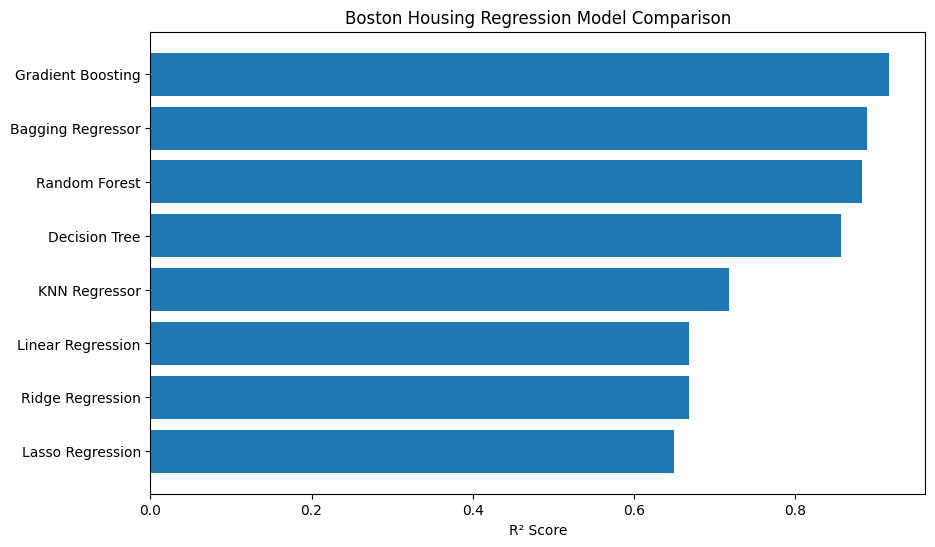

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["R2 Score"])
plt.xlabel("R² Score")
plt.title("Boston Housing Regression Model Comparison")
plt.gca().invert_yaxis()
plt.show()

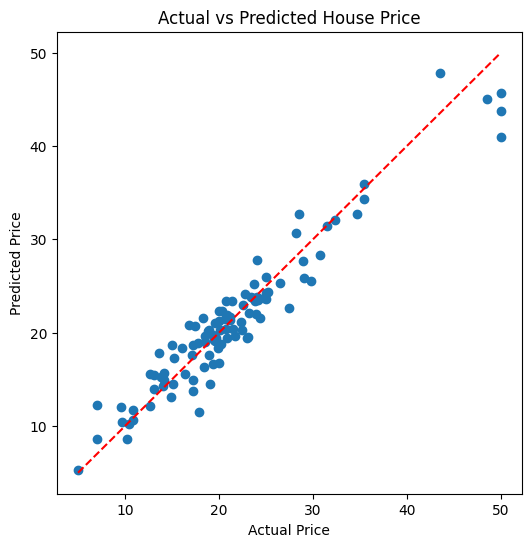

In [ ]:
best_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

Correlation Heatmap

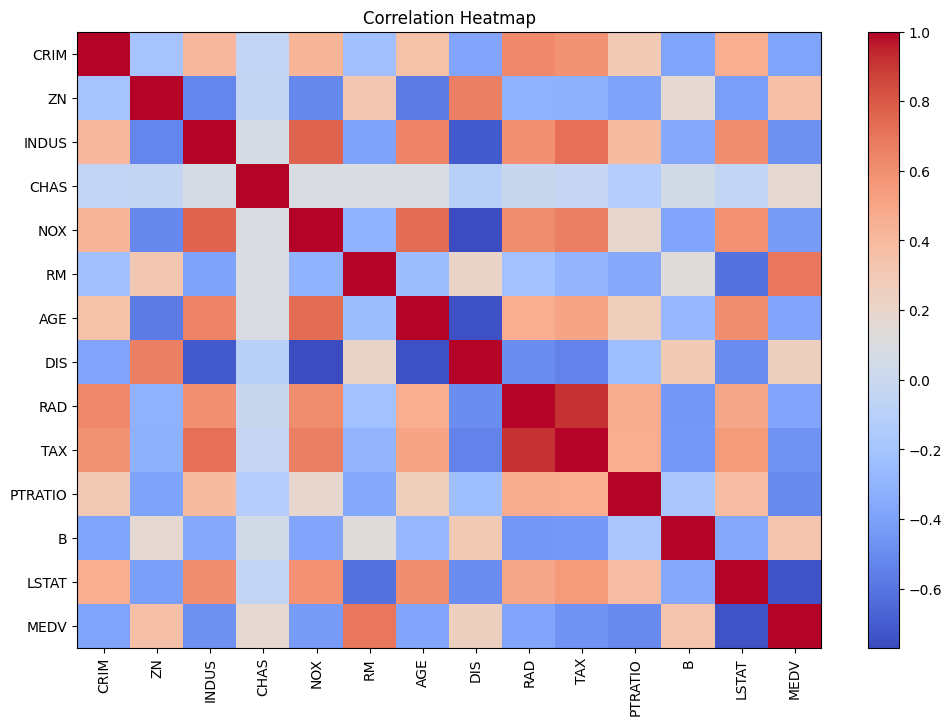

In [ ]:
|import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

House Price Distribution

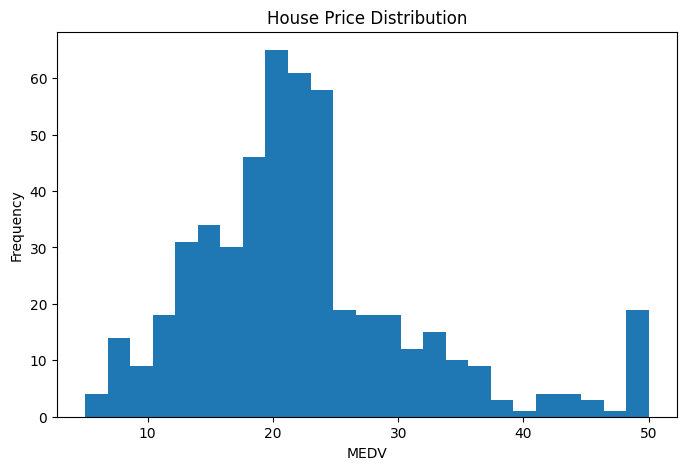

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["MEDV"], bins=25)
plt.title("House Price Distribution")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

Feature Importance

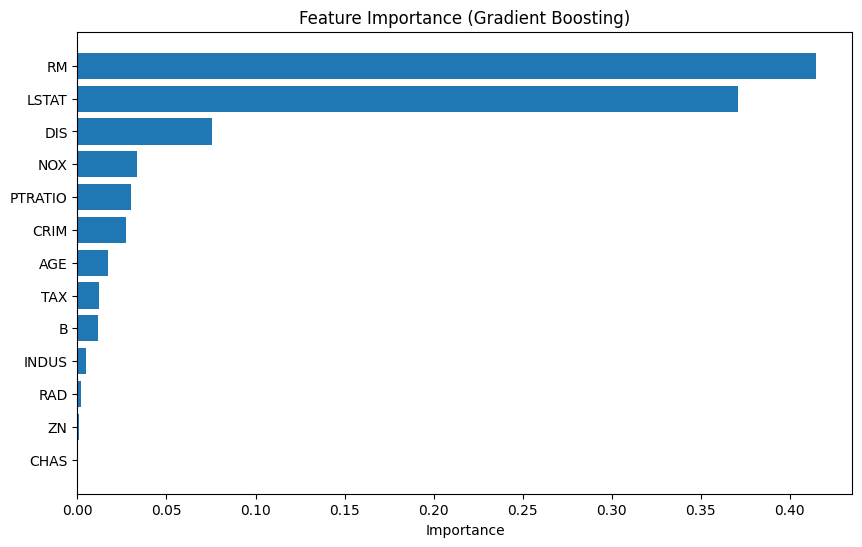

,Feature,Importance
5,RM,0.414592
12,LSTAT,0.370941
7,DIS,0.075434
4,NOX,0.033264
10,PTRATIO,0.029991
0,CRIM,0.027086
6,AGE,0.017166
9,TAX,0.011945
11,B,0.011728
2,INDUS,0.004567


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

importance

In [ ]:
sample = X.iloc[[0]]
prediction = best_model.predict(sample)

print("Predicted House Price:", prediction[0])
print("Actual House Price:", y.iloc[0])

Predicted House Price: 27.818218252870544
Actual House Price: 24.0


In [ ]:
best_model.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [ ]:
new_house = pd.DataFrame({
    "CRIM": [0.05],
    "ZN": [30.0],
    "INDUS": [4.0],
    "CHAS": [0],
    "NOX": [0.40],
    "RM": [7.0],
    "AGE": [30.0],
    "DIS": [6.0],
    "RAD": [4],
    "TAX": [250],
    "PTRATIO": [16.0],
    "B": [395.0],
    "LSTAT": [5.0]
})

prediction = best_model.predict(new_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 33.19681014665973


In [ ]:
new_house = pd.DataFrame({
    "CRIM": [5.0],
    "ZN": [0.0],
    "INDUS": [18.0],
    "CHAS": [0],
    "NOX": [0.70],
    "RM": [5.0],
    "AGE": [90.0],
    "DIS": [2.0],
    "RAD": [24],
    "TAX": [650],
    "PTRATIO": [20.0],
    "B": [300.0],
    "LSTAT": [25.0]
})

prediction = best_model.predict(new_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 11.03547132983997
